In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("Real_estates.csv")
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [3]:
df.info()
# no missing values
# object datatype-1 , Address
# target = Price, continuous , Regression type models

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


In [4]:
# checking for statistical distribution of data
df.describe()
# data is almost normally distributed
# checking it further

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price'],
      dtype='object')
Avg. Area Income


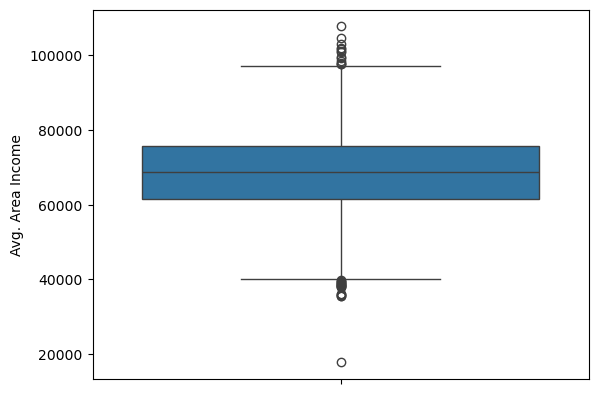

Avg. Area House Age


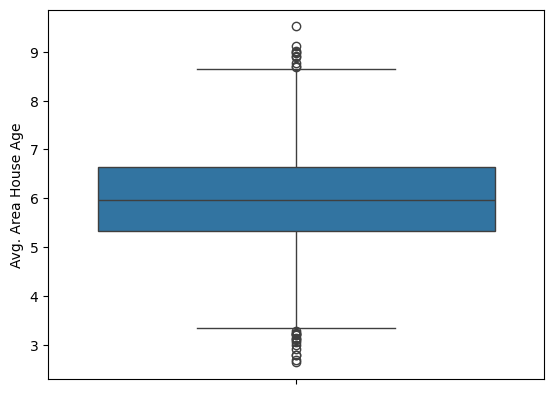

Avg. Area Number of Rooms


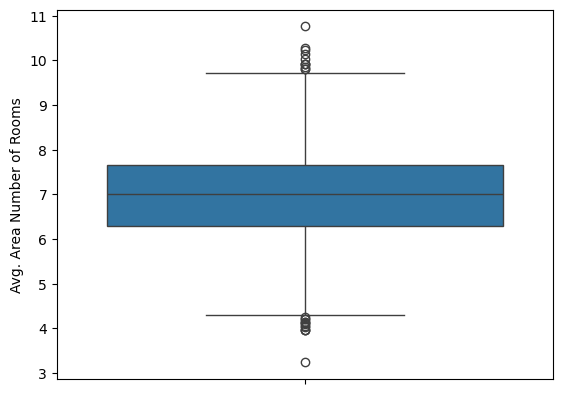

Avg. Area Number of Bedrooms


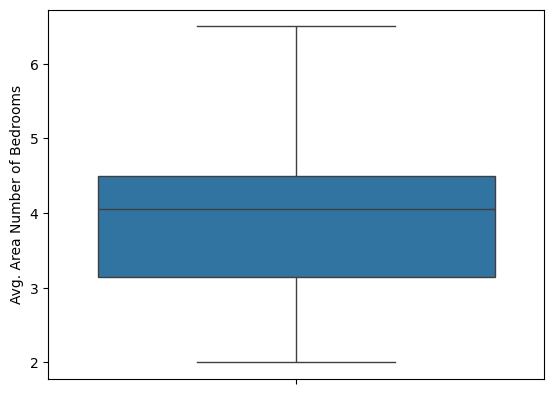

Area Population


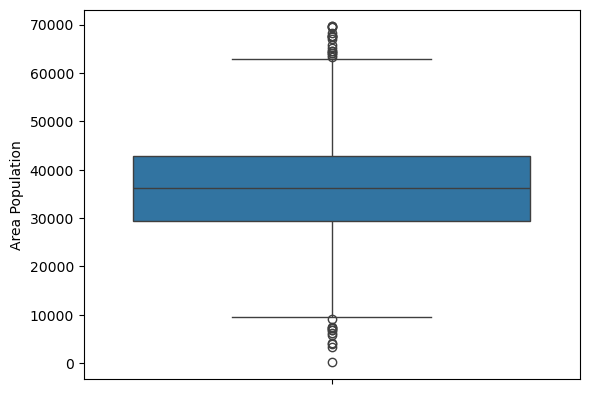

Price


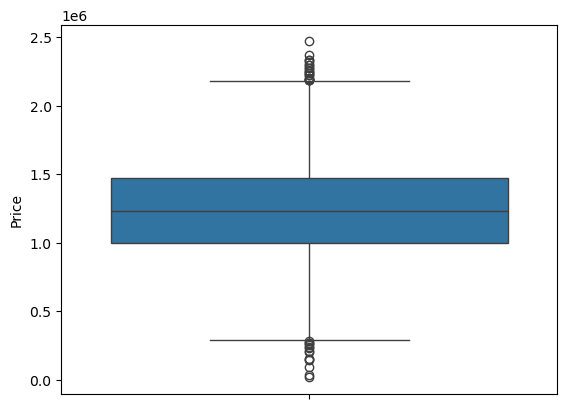

In [5]:
n_c=df.select_dtypes(["int","float"]).columns
print(n_c)
for i in n_c:
    print(i)
    sns.boxplot(df[i])
    plt.show()
# except Avg. Area Number of Bedrooms column  all have outliers

In [6]:
n_c

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price'],
      dtype='object')

In [7]:
def replacing_outliers(d):
    n=['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population']
    for i in n:
        q1=d[i].quantile(0.25)
        q3=d[i].quantile(0.75)
        iqr=q3-q1
        lw=q1-1.5*iqr
        uw=q3+1.5*iqr
        d[i]=d[i].apply(lambda x:min(max(x,lw),uw))
    return d

In [8]:
replacing_outliers(df)

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386
...,...,...,...,...,...,...,...
4995,60567.944140,7.830362,6.137356,3.46,22837.361035,1.060194e+06,USNS Williams\nFPO AP 30153-7653
4996,78491.275435,6.999135,6.576763,4.02,25616.115489,1.482618e+06,"PSC 9258, Box 8489\nAPO AA 42991-3352"
4997,63390.686886,7.250591,4.805081,2.13,33266.145490,1.030730e+06,"4215 Tracy Garden Suite 076\nJoshualand, VA 01..."
4998,68001.331235,5.534388,7.130144,5.44,42625.620156,1.198657e+06,USS Wallace\nFPO AE 73316


Avg. Area Income


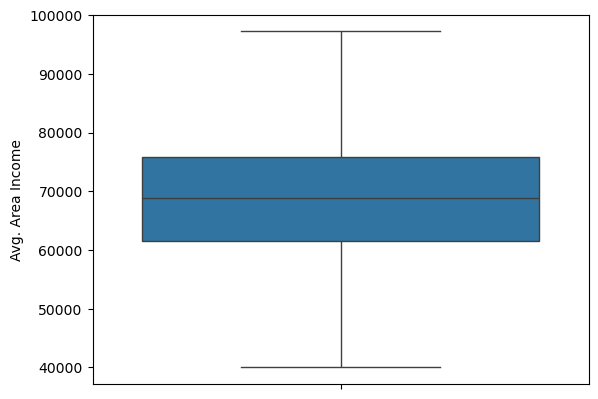

Avg. Area House Age


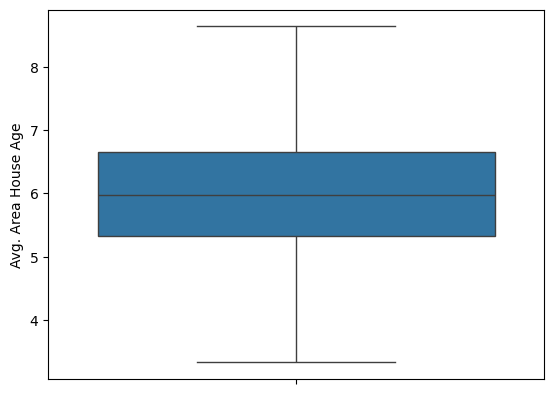

Avg. Area Number of Rooms


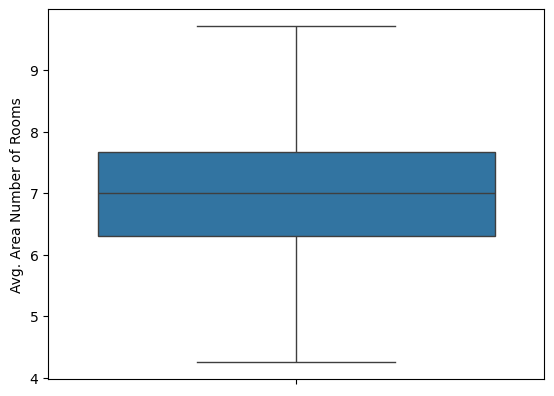

Avg. Area Number of Bedrooms


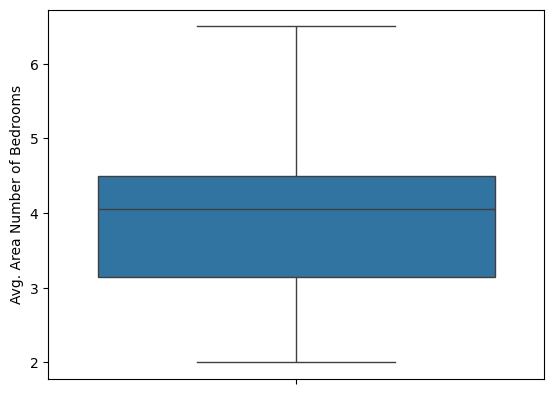

Area Population


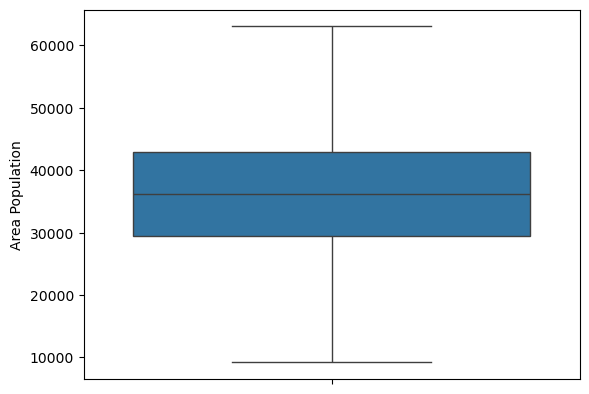

Price


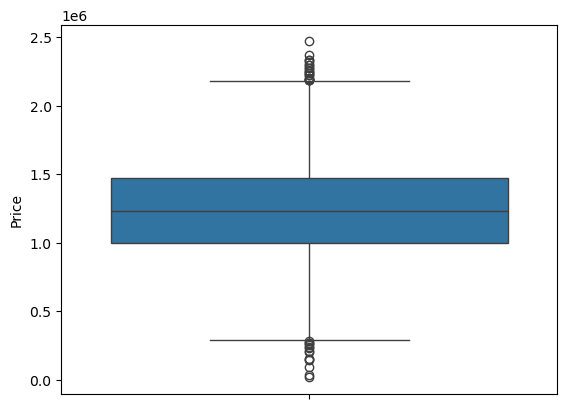

In [9]:
for i in n_c:
    print(i)
    sns.boxplot(df[i])
    plt.show()

In [10]:
# skewness check
from scipy.stats import skew
for i in n_c:
    print(f"{i} : {skew(df[i])}")
# between -0.5 to 0.5. So skewness not present

Avg. Area Income : -0.023639957416688714
Avg. Area House Age : -0.0016972199770896312
Avg. Area Number of Rooms : -0.045752420624907066
Avg. Area Number of Bedrooms : 0.37612751568905145
Area Population : 0.0412054528138087
Price : -0.0027172494461181608


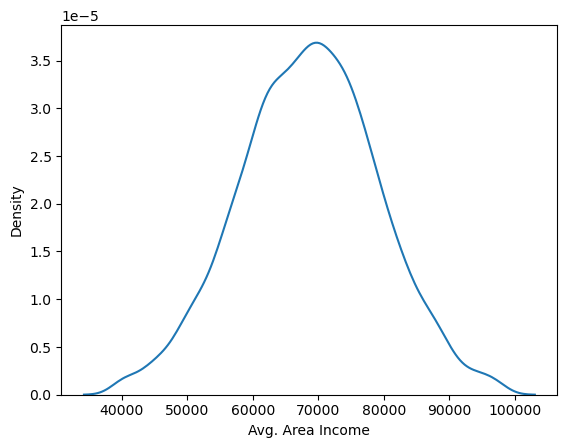

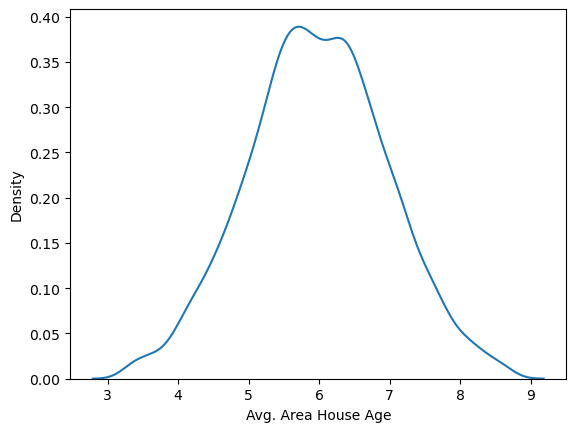

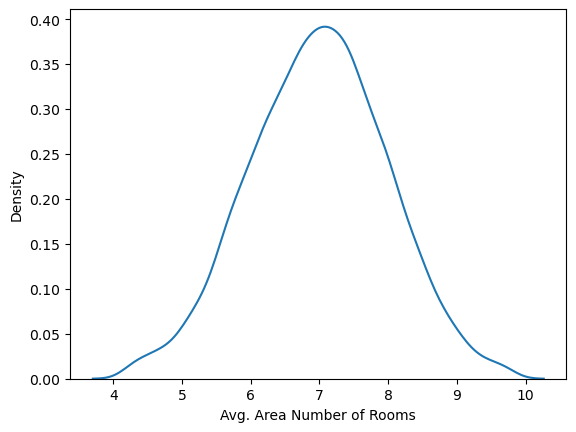

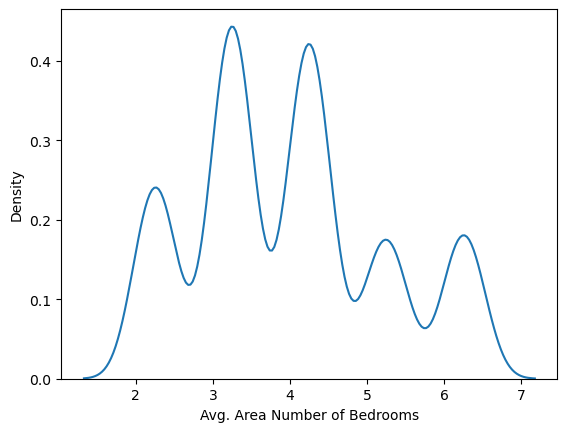

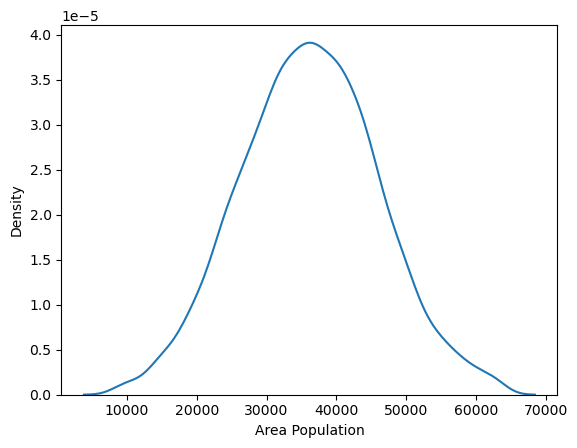

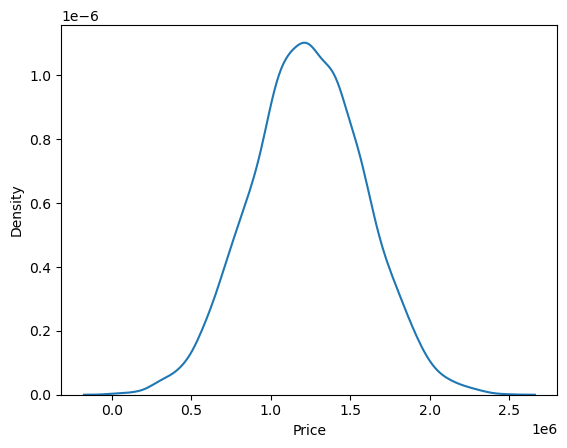

In [11]:
for i in n_c:
    sns.kdeplot(df[i])
    plt.show()

In [12]:
# object encoding

In [13]:
o_c=df.select_dtypes("object").columns
for i in o_c:
    print(f"{i} : {df[i].nunique()} {df[i].value_counts()}")

Address : 5000 Address
37778 George Ridges Apt. 509\nEast Holly, NV 29290-3595    1
208 Michael Ferry Apt. 674\nLaurabury, NE 37010-5101       1
188 Johnson Views Suite 079\nLake Kathleen, CA 48958       1
9127 Elizabeth Stravenue\nDanieltown, WI 06482-3489        1
USS Barnett\nFPO AP 44820                                  1
                                                          ..
209 Natasha Stream Suite 961\nHuffmanland, NE 52457        1
911 Castillo Park Apt. 717\nDavisborough, PW 78603         1
6368 John Motorway Suite 700\nJanetbury, NM 26854          1
Unit 9446 Box 0958\nDPO AE 97025                           1
USS Gilbert\nFPO AA 20957                                  1
Name: count, Length: 5000, dtype: int64


In [14]:
df.drop("Address",axis=1,inplace=True)

In [15]:
n_c

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price'],
      dtype='object')

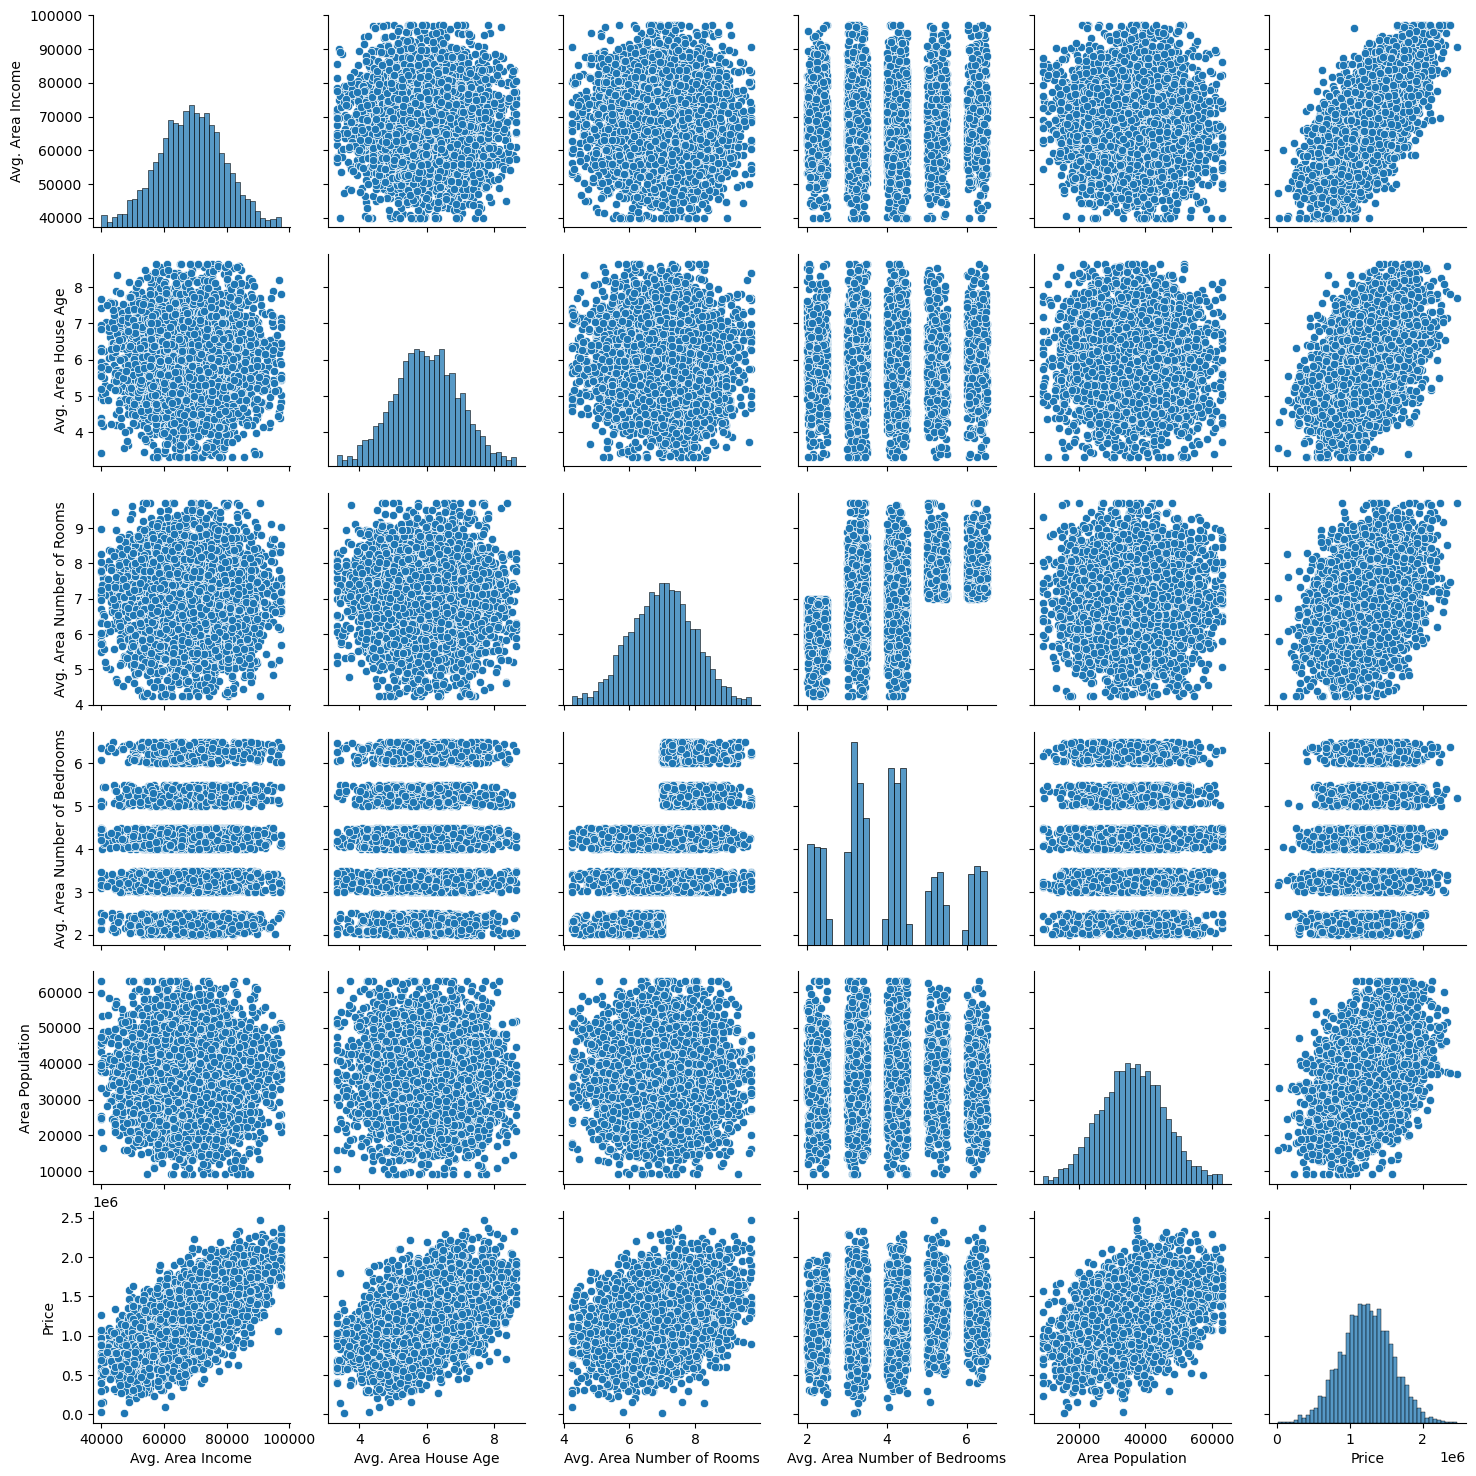

In [16]:
sns.pairplot(df[n_c])#

<Axes: >

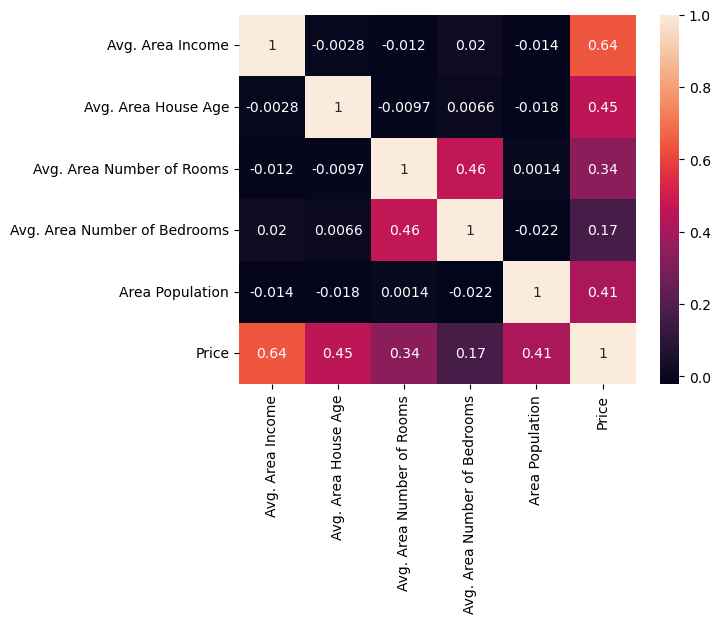

In [17]:
sns.heatmap(df[n_c].corr(),annot=True)

In [18]:
features=df.drop("Price",axis=1)
target=df["Price"]

In [19]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
features.iloc[:]=ss.fit_transform(features.iloc[:])
features

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population
0,1.034822,-0.298541,0.021527,0.088062,-1.325622
1,1.006797,0.025747,-0.256355,-0.722301,0.407049
2,-0.689128,-0.113082,1.522445,0.930840,0.073326
3,-0.494796,1.226822,-1.398453,-0.584540,-0.187484
4,-0.812333,-0.949376,0.850279,0.201513,-0.994293
...,...,...,...,...,...
4995,-0.757027,1.877474,-0.848785,-0.422467,-1.350917
4996,0.935287,1.035210,-0.410145,0.031337,-1.069131
4997,-0.490505,1.290004,-2.178738,-1.500251,-0.293363
4998,-0.055170,-0.448985,0.142272,1.182053,0.655755


In [20]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(features,target,random_state=1,test_size=0.20)

In [21]:
print(xtrain.shape,ytrain.shape)
print(xtest.shape,ytest.shape)

(4000, 5) (4000,)
(1000, 5) (1000,)


In [22]:
features

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population
0,1.034822,-0.298541,0.021527,0.088062,-1.325622
1,1.006797,0.025747,-0.256355,-0.722301,0.407049
2,-0.689128,-0.113082,1.522445,0.930840,0.073326
3,-0.494796,1.226822,-1.398453,-0.584540,-0.187484
4,-0.812333,-0.949376,0.850279,0.201513,-0.994293
...,...,...,...,...,...
4995,-0.757027,1.877474,-0.848785,-0.422467,-1.350917
4996,0.935287,1.035210,-0.410145,0.031337,-1.069131
4997,-0.490505,1.290004,-2.178738,-1.500251,-0.293363
4998,-0.055170,-0.448985,0.142272,1.182053,0.655755


In [24]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(xtrain, ytrain) # training
ypred=reg.predict(xtest)
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
mae=mean_absolute_error(ytest, ypred)
mse=mean_squared_error(ytest, ypred)
rmse=np.sqrt(mse)
r2=r2_score(ytest,ypred)
print(f"mae : {mae}")
print(f"mse : {mse}")
print(f"rmse : {rmse}")
print(f"r2 (Model Accuarcy) : {r2}")

mae : 82941.42659186163
mse : 10700616374.625954
rmse : 103443.78364418983
r2 (Model Accuarcy) : 0.9204258661172101


In [26]:
d=pd.DataFrame({"columns":xtrain.columns,
               "slope":reg.coef_})
d

,columns,slope
0,Avg. Area Income,230817.112565
1,Avg. Area House Age,163851.653474
2,Avg. Area Number of Rooms,121813.003710
3,Avg. Area Number of Bedrooms,1585.350933
4,Area Population,149984.269644


In [27]:
reg.intercept_

np.float64(1233146.8019568857)

In [ ]:
# Assumptions of linear regression 
# (atleast 3 out of 4 should be satisfied)
# Linearity and independence: features and target are linearly related, 
# and fetures are independent of each other
# No multicollinearity : assumption failed
# Homoscedasticity : constant variance property is satisfied
# Normality :  Satisfied.

<Axes: ylabel='Price'>

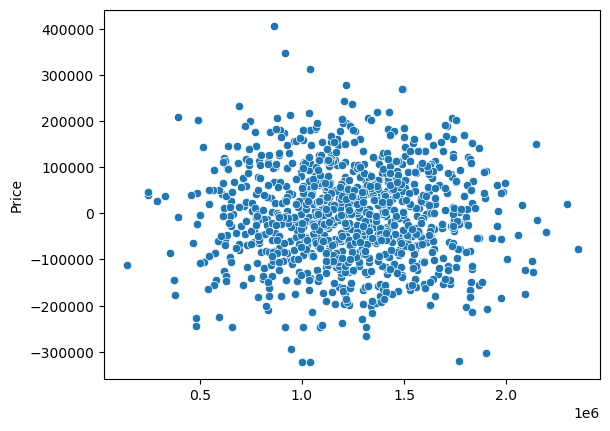

In [30]:
sns.scatterplot(x=ypred,y=(ytest-ypred)) # constant variance

<Axes: xlabel='Price', ylabel='Density'>

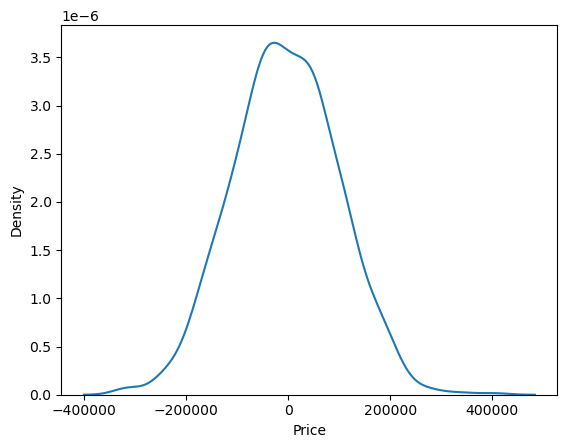

In [31]:
sns.kdeplot((ytest-ypred)) # normality of residuals